# Logistics Analysis Report
## US State Demographics, Fuel Pricing & Efficiency Metrics

**Objective**: Analyze shipping logistics across 50 US states, focusing on population demographics, fuel cost burdens, and regional efficiency patterns.

**Data Period**: Current run (pipeline_run_id: unique)

**Key Questions**:
1. How does state population correlate with fuel prices?
2. Which states have the highest fuel cost burden?
3. What are regional patterns in logistics efficiency?
4. Which states are most/least efficient for shipping operations?

## 1. Setup & Data Loading

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Change to project directory
project_dir = Path(r'c:\Users\JUAN\DashLogistics')
os.chdir(project_dir)

# Configure visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
enriched_path = Path('data/final/enriched_data.csv')
df = pd.read_csv(enriched_path)

print(f'Data loaded successfully!')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()

Data loaded successfully!
Shape: (50, 10)
Columns: ['rank', 'state', 'postal', 'population', 'population_per_rank', 'regular', 'mid_grade', 'premium', 'diesel', 'pipeline_run_id']

First 5 rows:


,rank,state,postal,population,population_per_rank,regular,mid_grade,premium,diesel,pipeline_run_id
0,5,CA,CA,38802500.0,7.760500e+06,5.368,5.589,5.774,6.209,a14ebd7bb862487d98df22fef7fdb533
1,45,TX,TX,26956958.0,5.990435e+05,3.262,3.763,4.128,4.567,a14ebd7bb862487d98df22fef7fdb533
2,10,FL,FL,19893297.0,1.989330e+06,3.718,4.155,4.475,5.074,a14ebd7bb862487d98df22fef7fdb533
3,33,NY,NY,19746227.0,5.983705e+05,3.521,4.006,4.395,4.993,a14ebd7bb862487d98df22fef7fdb533
4,14,IL,IL,12880580.0,9.200414e+05,3.662,4.213,4.688,4.773,a14ebd7bb862487d98df22fef7fdb533


In [4]:
# Import KPI and Feature classes
try:
    from src.analysis.kpis import KPIAnalysis
    from src.analysis.features import FeatureEngineering
    print('✅ Analysis modules imported successfully')
except ImportError as e:
    print(f'⚠️  Some modules not available: {e}')
    print('   Proceeding with core analysis...')

✅ Analysis modules imported successfully


## 2. Data Overview & Quality Check

In [5]:
# Data quality summary
print('=== DATA QUALITY REPORT ===')
print(f'Total states: {len(df)}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nStatistical summary:')
df.describe()

=== DATA QUALITY REPORT ===
Total states: 50
Missing values:
rank                   0
state                  0
postal                 0
population             0
population_per_rank    0
regular                0
mid_grade              0
premium                0
diesel                 0
pipeline_run_id        0
dtype: int64

Data types:
rank                     int64
state                   object
postal                  object
population             float64
population_per_rank    float64
regular                float64
mid_grade              float64
premium                float64
diesel                 float64
pipeline_run_id         object
dtype: object

Statistical summary:


,rank,population,population_per_rank,regular,mid_grade,premium,diesel
count,50.00000,5.000000e+01,5.000000e+01,50.00000,50.000000,50.000000,50.000000
mean,26.58000,6.363963e+06,5.671708e+05,3.52660,3.941840,4.319500,4.773700
std,15.13489,7.150942e+06,1.295530e+06,0.46598,0.434981,0.398952,0.402044
min,1.00000,5.841530e+05,1.123371e+04,3.04000,3.332000,3.726000,4.056000
25%,14.25000,1.858120e+06,9.954494e+04,3.22975,3.686500,4.058500,4.526750
50%,26.50000,4.531566e+06,1.838299e+05,3.44250,3.916500,4.287500,4.826500
75%,38.75000,6.982500e+06,4.152397e+05,3.52325,4.074250,4.463750,4.939000
max,52.00000,3.880250e+07,7.760500e+06,5.36800,5.589000,5.774000,6.209000


## 3. Fuel Price Analysis

In [6]:
# Calculate average fuel prices
fuel_cols = ['regular', 'mid_grade', 'premium', 'diesel']
avg_prices = df[fuel_cols].mean()

print('=== AVERAGE FUEL PRICES (USD/Gallon) ===')
for fuel_type, price in avg_prices.items():
    print(f'{fuel_type.upper():12} ${price:.3f}')

print(f'\nPrice range (Regular Gas):')
print(f'  MIN: ${df["regular"].min():.3f}')
print(f'  MAX: ${df["regular"].max():.3f}')
print(f'  RANGE: ${df["regular"].max() - df["regular"].min():.3f}')

=== AVERAGE FUEL PRICES (USD/Gallon) ===
REGULAR      $3.527
MID_GRADE    $3.942
PREMIUM      $4.320
DIESEL       $4.774

Price range (Regular Gas):
  MIN: $3.040
  MAX: $5.368
  RANGE: $2.328


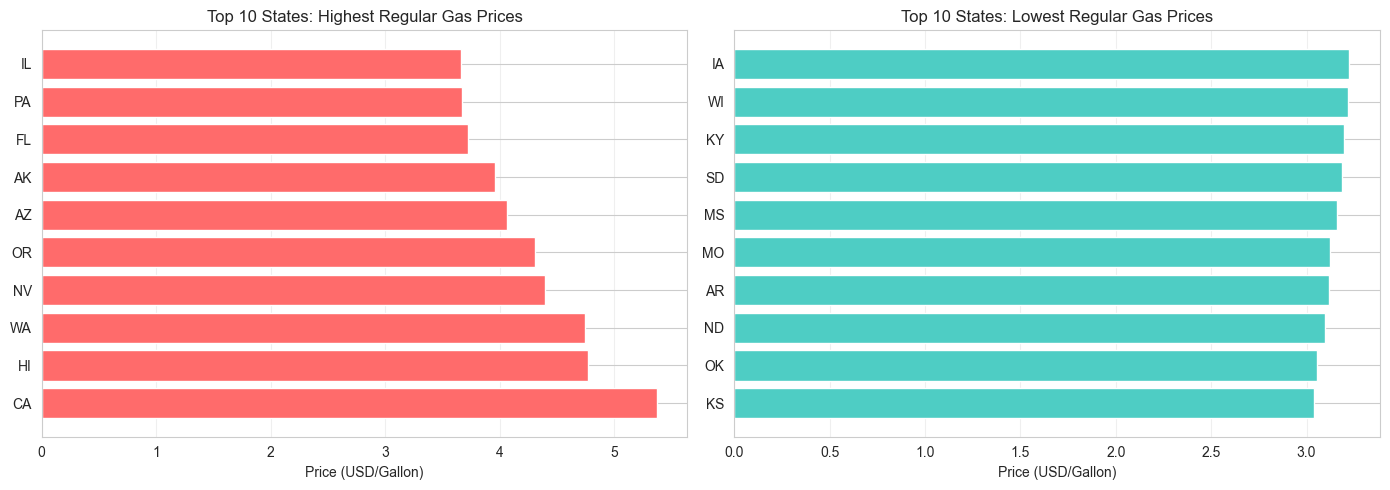


=== TOP 5 MOST EXPENSIVE (Regular Gas) ===
CA $5.368
HI $4.768
WA $4.741
NV $4.397
OR $4.305

=== TOP 5 CHEAPEST (Regular Gas) ===
KS $3.040
OK $3.055
ND $3.098
AR $3.116
MO $3.123


In [7]:
# Fuel prices by state - top and bottom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 most expensive
top_10_regular = df.nlargest(10, 'regular')[['state', 'regular']]
axes[0].barh(top_10_regular['state'], top_10_regular['regular'], color='#FF6B6B')
axes[0].set_xlabel('Price (USD/Gallon)')
axes[0].set_title('Top 10 States: Highest Regular Gas Prices')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 10 least expensive
bottom_10_regular = df.nsmallest(10, 'regular')[['state', 'regular']]
axes[1].barh(bottom_10_regular['state'], bottom_10_regular['regular'], color='#4ECDC4')
axes[1].set_xlabel('Price (USD/Gallon)')
axes[1].set_title('Top 10 States: Lowest Regular Gas Prices')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== TOP 5 MOST EXPENSIVE (Regular Gas) ===')
for idx, row in df.nlargest(5, 'regular').iterrows():
    print(f"{row['state']:2} ${row['regular']:.3f}")

print('\n=== TOP 5 CHEAPEST (Regular Gas) ===')
for idx, row in df.nsmallest(5, 'regular').iterrows():
    print(f"{row['state']:2} ${row['regular']:.3f}")

## 4. Population & Fuel Burden Analysis

Correlation Matrix:
            population   regular    diesel
population    1.000000  0.398121  0.479541
regular       0.398121  1.000000  0.830485
diesel        0.479541  0.830485  1.000000


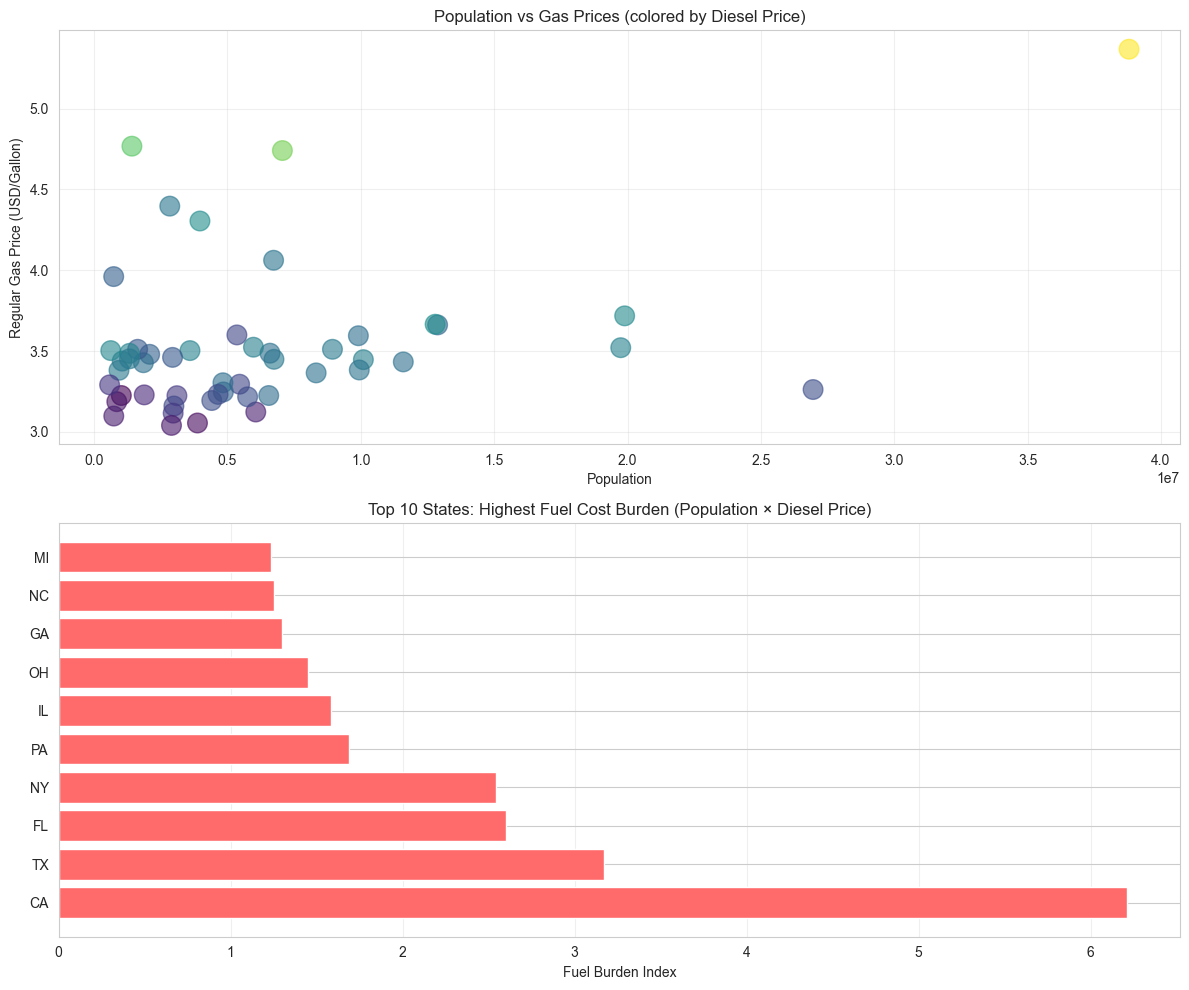

In [8]:
# Calculate fuel burden index (population-weighted fuel cost)
df['fuel_burden_index'] = (df['population'] / df['population'].max()) * df['diesel']

# Top 10 states by fuel burden
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Population vs Regular Gas Price scatter
axes[0].scatter(df['population'], df['regular'], s=200, alpha=0.6, c=df['diesel'], cmap='viridis')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Regular Gas Price (USD/Gallon)')
axes[0].set_title('Population vs Gas Prices (colored by Diesel Price)')
axes[0].grid(alpha=0.3)

# Correlation analysis
corr = df[['population', 'regular', 'diesel']].corr()
print('Correlation Matrix:')
print(corr)

# Top fuel burden states
top_burden = df.nlargest(10, 'fuel_burden_index')[['state', 'population', 'diesel', 'fuel_burden_index']]
axes[1].barh(top_burden['state'], top_burden['fuel_burden_index'], color='#FF6B6B')
axes[1].set_xlabel('Fuel Burden Index')
axes[1].set_title('Top 10 States: Highest Fuel Cost Burden (Population × Diesel Price)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Regional Efficiency Metrics

In [9]:
# Define regions
REGIONS = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'South': ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
    'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
    'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
}

# Assign regions to dataframe
def assign_region(state):
    for region, states in REGIONS.items():
        if state in states:
            return region
    return 'Other'

df['region'] = df['state'].apply(assign_region)

print(f'States by region: {df.groupby("region").size().to_dict()}')
print(f'\nRegional fuel price summary:')
print(df.groupby('region')[fuel_cols].mean().round(3))

States by region: {'Midwest': 12, 'Northeast': 9, 'South': 16, 'West': 13}

Regional fuel price summary:
           regular  mid_grade  premium  diesel
region                                        
Midwest      3.299      3.684    4.176   4.494
Northeast    3.503      4.032    4.431   4.989
South        3.315      3.790    4.158   4.729
West         4.013      4.305    4.573   4.937


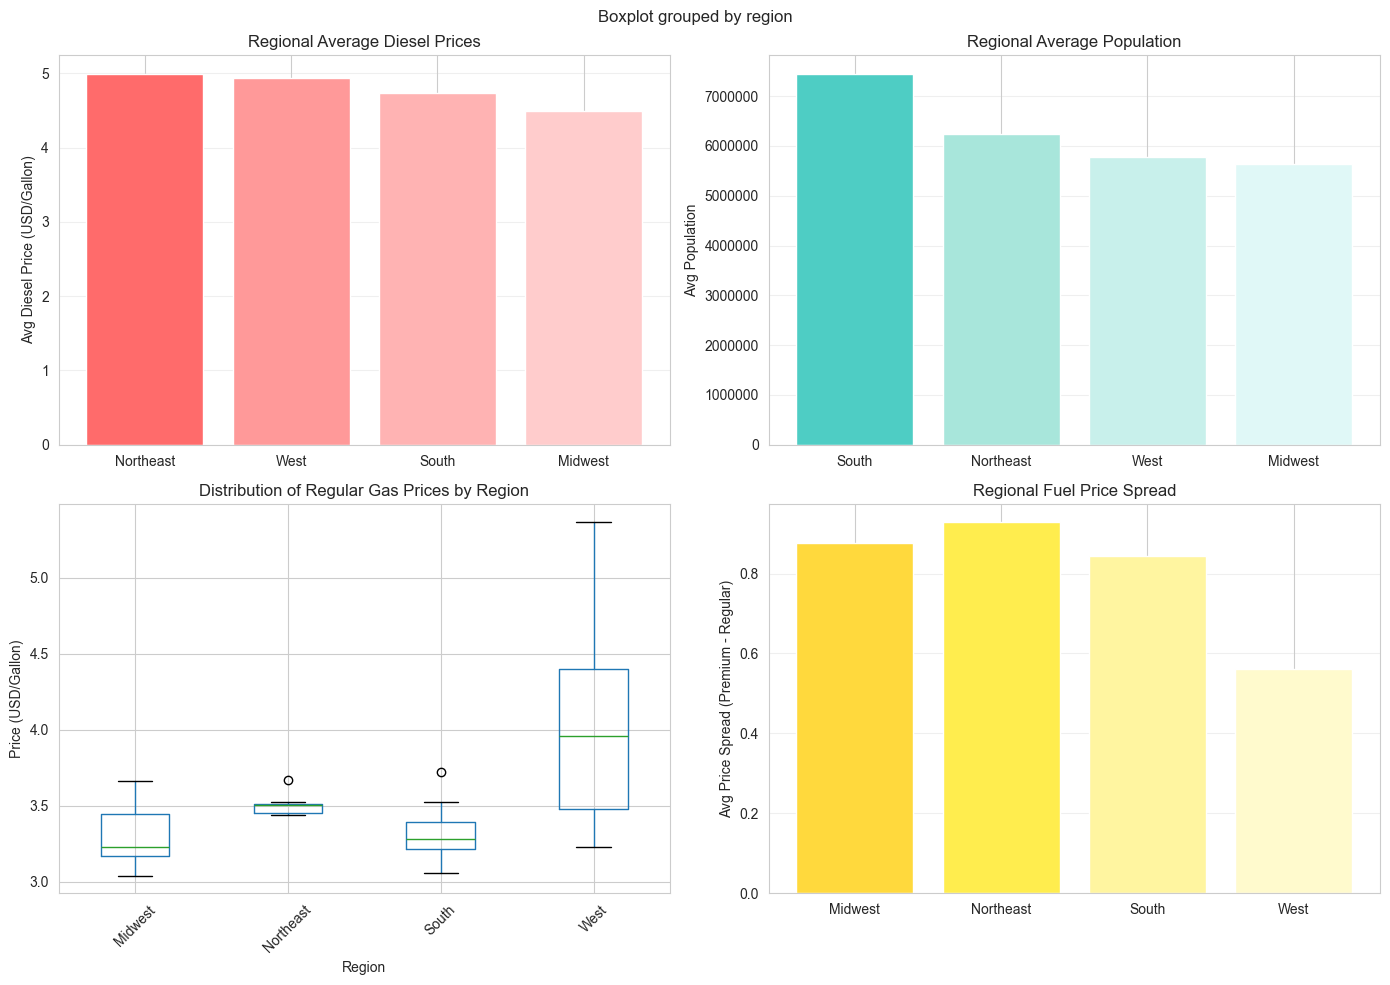

In [10]:
# Regional comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average diesel price by region
regional_diesel = df.groupby('region')['diesel'].mean().sort_values(ascending=False)
axes[0, 0].bar(regional_diesel.index, regional_diesel.values, color=['#FF6B6B', '#FF9999', '#FFB3B3', '#FFCCCC'])
axes[0, 0].set_ylabel('Avg Diesel Price (USD/Gallon)')
axes[0, 0].set_title('Regional Average Diesel Prices')
axes[0, 0].grid(axis='y', alpha=0.3)

# Average population by region
regional_pop = df.groupby('region')['population'].mean().sort_values(ascending=False)
axes[0, 1].bar(regional_pop.index, regional_pop.values, color=['#4ECDC4', '#A8E6DB', '#C8F0EB', '#E0F8F7'])
axes[0, 1].set_ylabel('Avg Population')
axes[0, 1].set_title('Regional Average Population')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='y')

# Box plot: fuel prices by region
df.boxplot(column='regular', by='region', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Regular Gas Prices by Region')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Price (USD/Gallon)')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Fuel price range by region (premium - regular)
df['fuel_price_spread'] = df['premium'] - df['regular']
regional_spread = df.groupby('region')['fuel_price_spread'].mean()
axes[1, 1].bar(regional_spread.index, regional_spread.values, color=['#FFD93D', '#FFED4E', '#FFF5A0', '#FFFACD'])
axes[1, 1].set_ylabel('Avg Price Spread (Premium - Regular)')
axes[1, 1].set_title('Regional Fuel Price Spread')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Efficiency Tiers & Rankings

In [11]:
# Create efficiency score (lower fuel cost = higher efficiency)
# Efficiency = population per unit of diesel cost
df['efficiency_score'] = df['population'] / (df['diesel'] * 100)  # normalized

# Normalize to 0-100 scale
df['efficiency_percentile'] = (df['efficiency_score'].rank(pct=True) * 100).round(1)

# Categorize as tiers
def tier_category(percentile):
    if percentile >= 75:
        return 'Top Tier (Highly Efficient)'
    elif percentile >= 50:
        return 'Mid Tier (Average)'
    elif percentile >= 25:
        return 'Low Tier (Below Average)'
    else:
        return 'Bottom Tier (Least Efficient)'

df['efficiency_tier'] = df['efficiency_percentile'].apply(tier_category)

print('=== EFFICIENCY TIER DISTRIBUTION ===')
print(df['efficiency_tier'].value_counts())
print(f'\n=== TOP 10 MOST EFFICIENT STATES ===')
top_eff = df.nlargest(10, 'efficiency_score')[['state', 'population', 'diesel', 'efficiency_score', 'efficiency_percentile']]
for idx, row in top_eff.iterrows():
    print(f"{row['state']:2} | Pop: {row['population']:,} | Diesel: ${row['diesel']:.3f} | Score: {row['efficiency_score']:.2f} | Percentile: {row['efficiency_percentile']:.0f}")

print(f'\n=== BOTTOM 10 LEAST EFFICIENT STATES ===')
bottom_eff = df.nsmallest(10, 'efficiency_score')[['state', 'population', 'diesel', 'efficiency_score', 'efficiency_percentile']]
for idx, row in bottom_eff.iterrows():
    print(f"{row['state']:2} | Pop: {row['population']:,} | Diesel: ${row['diesel']:.3f} | Score: {row['efficiency_score']:.2f} | Percentile: {row['efficiency_percentile']:.0f}")

=== EFFICIENCY TIER DISTRIBUTION ===
efficiency_tier
Top Tier (Highly Efficient)      13
Mid Tier (Average)               13
Low Tier (Below Average)         12
Bottom Tier (Least Efficient)    12
Name: count, dtype: int64

=== TOP 10 MOST EFFICIENT STATES ===
CA | Pop: 38,802,500.0 | Diesel: $6.209 | Score: 62493.96 | Percentile: 100
TX | Pop: 26,956,958.0 | Diesel: $4.567 | Score: 59025.53 | Percentile: 98
NY | Pop: 19,746,227.0 | Diesel: $4.993 | Score: 39547.82 | Percentile: 96
FL | Pop: 19,893,297.0 | Diesel: $5.074 | Score: 39206.34 | Percentile: 94
IL | Pop: 12,880,580.0 | Diesel: $4.773 | Score: 26986.34 | Percentile: 92
PA | Pop: 12,787,209.0 | Diesel: $5.116 | Score: 24994.54 | Percentile: 90
OH | Pop: 11,594,163.0 | Diesel: $4.850 | Score: 23905.49 | Percentile: 88
MI | Pop: 9,909,877.0 | Diesel: $4.835 | Score: 20496.13 | Percentile: 86
NC | Pop: 9,943,964.0 | Diesel: $4.878 | Score: 20385.33 | Percentile: 84
GA | Pop: 10,097,343.0 | Diesel: $4.989 | Score: 20239.21 | Perce

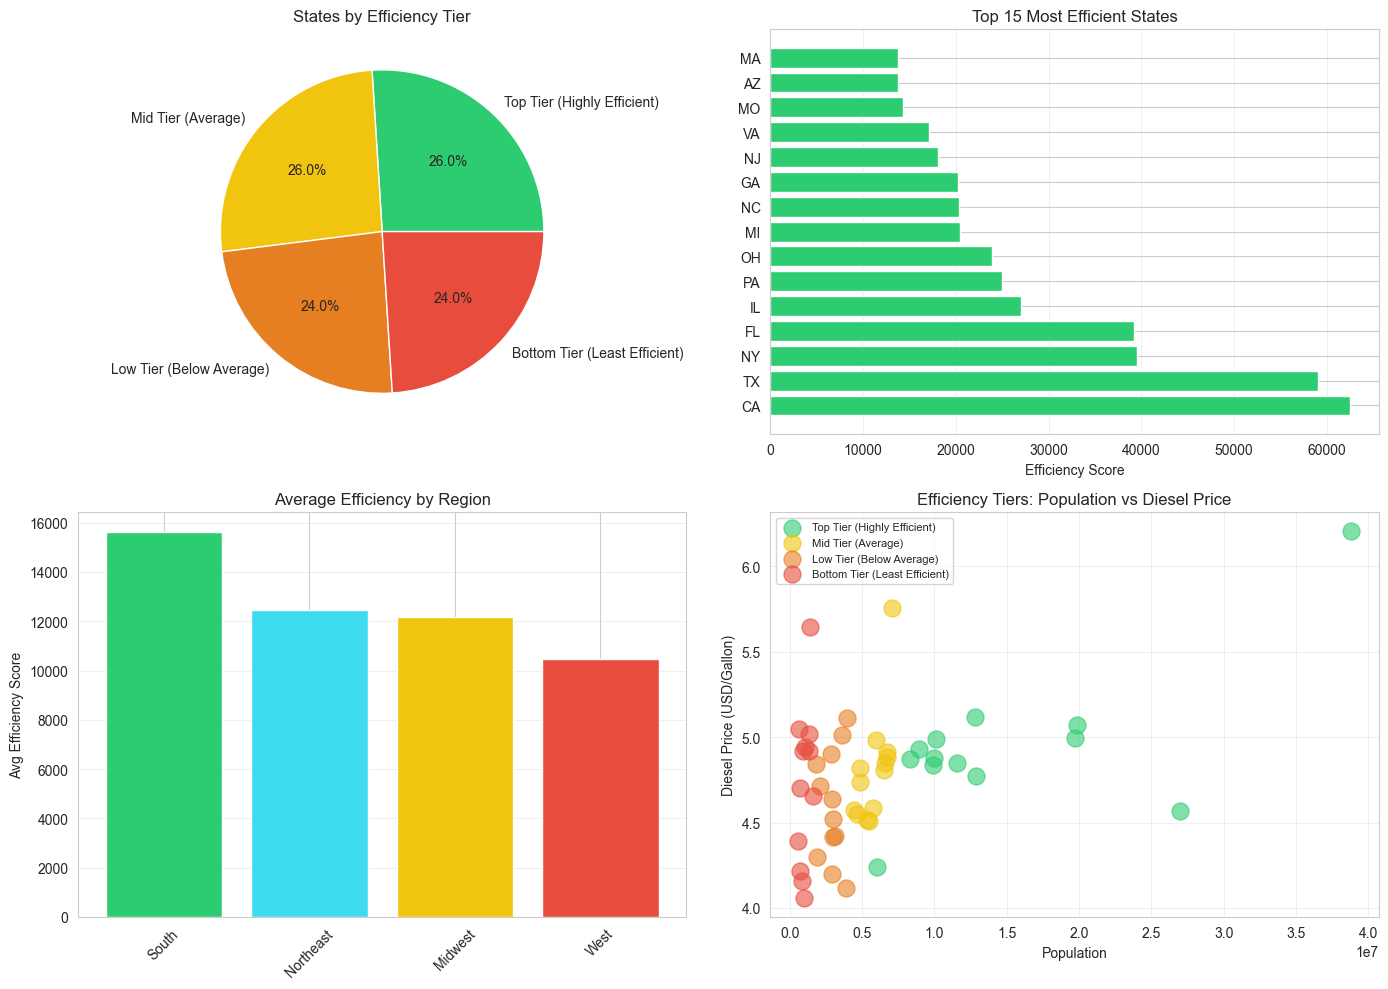

In [12]:
# Efficiency tier visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tier distribution pie chart
tier_counts = df['efficiency_tier'].value_counts()
colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
axes[0, 0].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%', colors=colors)
axes[0, 0].set_title('States by Efficiency Tier')

# Top 15 efficient states
top_15 = df.nlargest(15, 'efficiency_score')[['state', 'efficiency_score']]
axes[0, 1].barh(top_15['state'], top_15['efficiency_score'], color='#2ECC71')
axes[0, 1].set_xlabel('Efficiency Score')
axes[0, 1].set_title('Top 15 Most Efficient States')
axes[0, 1].grid(axis='x', alpha=0.3)

# Efficiency by region
regional_eff = df.groupby('region')['efficiency_score'].mean().sort_values(ascending=False)
axes[1, 0].bar(regional_eff.index, regional_eff.values, color=['#2ECC71', '#3EDBF0', '#F1C40F', '#E74C3C'])
axes[1, 0].set_ylabel('Avg Efficiency Score')
axes[1, 0].set_title('Average Efficiency by Region')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Scatter: efficiency vs population
for tier, color in [('Top Tier (Highly Efficient)', '#2ECC71'), 
                      ('Mid Tier (Average)', '#F1C40F'),
                      ('Low Tier (Below Average)', '#E67E22'),
                      ('Bottom Tier (Least Efficient)', '#E74C3C')]:
    mask = df['efficiency_tier'] == tier
    axes[1, 1].scatter(df[mask]['population'], df[mask]['diesel'], 
                       s=150, alpha=0.6, label=tier, color=color)
axes[1, 1].set_xlabel('Population')
axes[1, 1].set_ylabel('Diesel Price (USD/Gallon)')
axes[1, 1].set_title('Efficiency Tiers: Population vs Diesel Price')
axes[1, 1].legend(loc='best', fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Insights & Recommendations

In [13]:
print('=== KEY FINDINGS AND RECOMMENDATIONS ===')
print()

print('1. FUEL PRICE VARIATIONS')
print(f'   • Highest Regular Gas: {df.nlargest(1, "regular").iloc[0]["state"]} (${df["regular"].max():.3f})')
print(f'   • Lowest Regular Gas: {df.nsmallest(1, "regular").iloc[0]["state"]} (${df["regular"].min():.3f})')
print(f'   • Price Range: ${df["regular"].max() - df["regular"].min():.3f} per gallon')
print(f'   → RECOMMENDATION: Route heavy shipments through low-cost states when possible')
print()

print('2. REGIONAL PATTERNS')
for region in df['region'].unique():
    avg_diesel = df[df['region'] == region]['diesel'].mean()
    avg_pop = df[df['region'] == region]['population'].mean()
    count = len(df[df['region'] == region])
    print(f'   • {region:12} ({count:2} states): Avg Diesel ${avg_diesel:.3f}, Avg Pop {avg_pop:,.0f}')
print()

print('3. HIGH-EFFICIENCY OPPORTUNITIES')
top_tier = df[df['efficiency_tier'] == 'Top Tier (Highly Efficient)']['state'].tolist()
print(f'   • {len(top_tier)} states in Top Tier (75th+ percentile)')
print(f'   • Top tier states: {" ".join(top_tier[:10])}...')
print(f'   → RECOMMENDATION: Prioritize logistics hubs in these states')
print()

print('4. HIGH-BURDEN AREAS')
bottom_tier = df[df['efficiency_tier'] == 'Bottom Tier (Least Efficient)']['state'].tolist()
print(f'   • {len(bottom_tier)} states in Bottom Tier (<25th percentile)')
print(f'   • Bottom tier states: {" ".join(bottom_tier[:10])}...')
print(f'   → RECOMMENDATION: Apply premium surcharges or optimize routing for these regions')
print()

print('5. POPULATION-FUEL CORRELATION')
corr_pop_diesel = df['population'].corr(df['diesel'])
print(f'   • Population-Diesel correlation: {corr_pop_diesel:.3f}')
if abs(corr_pop_diesel) < 0.3:
    print(f'   → No strong link between population size and diesel prices')
elif corr_pop_diesel > 0:
    print(f'   → Larger states tend to have higher diesel costs')
else:
    print(f'   → Larger states tend to have lower diesel costs')
print()

print('6. COST OPTIMIZATION POTENTIAL')
total_diesel_cost = (df['population'] * df['diesel']).sum()
avg_scenario = (df['population'] * df['diesel'].mean()).sum()
savings = total_diesel_cost - avg_scenario
print(f'   • Theoretical savings if all states matched avg diesel price: ${-savings:,.0f}')
print(f'   → RECOMMENDATION: Develop regional partnerships to reduce premium pricing')

=== KEY FINDINGS AND RECOMMENDATIONS ===

1. FUEL PRICE VARIATIONS
   • Highest Regular Gas: CA ($5.368)
   • Lowest Regular Gas: KS ($3.040)
   • Price Range: $2.328 per gallon
   → RECOMMENDATION: Route heavy shipments through low-cost states when possible

2. REGIONAL PATTERNS
   • West         (13 states): Avg Diesel $4.937, Avg Pop 5,783,668
   • South        (16 states): Avg Diesel $4.729, Avg Pop 7,444,565
   • Northeast    ( 9 states): Avg Diesel $4.989, Avg Pop 6,239,148
   • Midwest      (12 states): Avg Diesel $4.494, Avg Pop 5,645,426

3. HIGH-EFFICIENCY OPPORTUNITIES
   • 13 states in Top Tier (75th+ percentile)
   • Top tier states: CA TX FL NY IL PA OH GA NC MI...
   → RECOMMENDATION: Prioritize logistics hubs in these states

4. HIGH-BURDEN AREAS
   • 12 states in Bottom Tier (<25th percentile)
   • Bottom tier states: ID HI ME NH RI MT DE SD ND AK...
   → RECOMMENDATION: Apply premium surcharges or optimize routing for these regions

5. POPULATION-FUEL CORRELATION
   •

## 8. Data Export for Further Analysis

In [14]:
# Export enriched analysis dataset
export_cols = ['state', 'postal', 'region', 'population', 'regular', 'mid_grade', 
                'premium', 'diesel', 'fuel_burden_index', 'efficiency_score', 
                'efficiency_percentile', 'efficiency_tier']

df_export = df[export_cols].copy()
df_export = df_export.sort_values('efficiency_score', ascending=False)

export_path = Path('data/final/logistics_analysis_enriched.csv')
df_export.to_csv(export_path, index=False)

print(f'✅ Analysis dataset exported to: {export_path}')
print(f'Records: {len(df_export)}')
print(f'\nSample output:')
display(df_export.head(10))

✅ Analysis dataset exported to: data\final\logistics_analysis_enriched.csv
Records: 50

Sample output:


,state,postal,region,population,regular,mid_grade,premium,diesel,fuel_burden_index,efficiency_score,efficiency_percentile,efficiency_tier
0,CA,CA,West,38802500.0,5.368,5.589,5.774,6.209,6.209000,62493.960380,100.0,Top Tier (Highly Efficient)
1,TX,TX,South,26956958.0,3.262,3.763,4.128,4.567,3.172796,59025.526604,98.0,Top Tier (Highly Efficient)
3,NY,NY,Northeast,19746227.0,3.521,4.006,4.395,4.993,2.540891,39547.820949,96.0,Top Tier (Highly Efficient)
2,FL,FL,South,19893297.0,3.718,4.155,4.475,5.074,2.601342,39206.340166,94.0,Top Tier (Highly Efficient)
4,IL,IL,Midwest,12880580.0,3.662,4.213,4.688,4.773,1.584408,26986.339828,92.0,Top Tier (Highly Efficient)
5,PA,PA,Northeast,12787209.0,3.666,4.089,4.463,5.116,1.685957,24994.544566,90.0,Top Tier (Highly Efficient)
6,OH,OH,Midwest,11594163.0,3.433,3.955,4.464,4.850,1.449177,23905.490722,88.0,Top Tier (Highly Efficient)
9,MI,MI,Midwest,9909877.0,3.595,4.171,4.734,4.835,1.234824,20496.126163,86.0,Top Tier (Highly Efficient)
8,NC,NC,South,9943964.0,3.383,3.853,4.241,4.878,1.250091,20385.330053,84.0,Top Tier (Highly Efficient)
7,GA,GA,South,10097343.0,3.447,3.913,4.321,4.989,1.298258,20239.212267,82.0,Top Tier (Highly Efficient)


## 9. Executive Summary

In [15]:
summary = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║           US LOGISTICS ANALYSIS - EXECUTIVE SUMMARY                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
   • Total States Analyzed: {len(df)}
   • Total Population Covered: {df['population'].sum():,.0f}
   • Data Collection Date: Current Run

⛽ FUEL PRICING INSIGHTS
   • Regular Gas Range: ${df['regular'].min():.3f} - ${df['regular'].max():.3f}
   • Average Diesel Price: ${df['diesel'].mean():.3f}
   • Most Expensive: {df.nlargest(1, 'regular').iloc[0]['state']} (${df['regular'].max():.3f})
   • Cheapest: {df.nsmallest(1, 'regular').iloc[0]['state']} (${df['regular'].min():.3f})

🌍 REGIONAL ANALYSIS
   • Northeast: {len(df[df['region'] == 'Northeast'])} states, Avg Diesel ${df[df['region'] == 'Northeast']['diesel'].mean():.3f}
   • South: {len(df[df['region'] == 'South'])} states, Avg Diesel ${df[df['region'] == 'South']['diesel'].mean():.3f}
   • Midwest: {len(df[df['region'] == 'Midwest'])} states, Avg Diesel ${df[df['region'] == 'Midwest']['diesel'].mean():.3f}
   • West: {len(df[df['region'] == 'West'])} states, Avg Diesel ${df[df['region'] == 'West']['diesel'].mean():.3f}

📈 EFFICIENCY TIERS
   • Top Tier States: {len(df[df['efficiency_tier'] == 'Top Tier (Highly Efficient)'])} best performers
   • Mid Tier States: {len(df[df['efficiency_tier'] == 'Mid Tier (Average)'])} average performers
   • Low Tier States: {len(df[df['efficiency_tier'] == 'Low Tier (Below Average)'])} underperformers
   • Bottom Tier States: {len(df[df['efficiency_tier'] == 'Bottom Tier (Least Efficient)'])} worst performers

💡 KEY RECOMMENDATIONS
   1. Focus shipping hubs in Top Tier states for cost efficiency
   2. Implement premium surcharges for Bottom Tier region shipments
   3. Develop regional partnerships to negotiate better fuel rates
   4. Route heavy loads through lowest-cost corridors
   5. Monitor quarterly fuel price trends for dynamic pricing strategy

📁 ANALYSIS OUTPUTS
   • Main Report: notebooks/01_LOGISTICS_ANALYSIS_REPORT.ipynb
   • Enriched Dataset: data/final/logistics_analysis_enriched.csv
   • Source Data: data/final/enriched_data.csv
"""

print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║           US LOGISTICS ANALYSIS - EXECUTIVE SUMMARY                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
   • Total States Analyzed: 50
   • Total Population Covered: 318,198,162
   • Data Collection Date: Current Run

⛽ FUEL PRICING INSIGHTS
   • Regular Gas Range: $3.040 - $5.368
   • Average Diesel Price: $4.774
   • Most Expensive: CA ($5.368)
   • Cheapest: KS ($3.040)

🌍 REGIONAL ANALYSIS
   • Northeast: 9 states, Avg Diesel $4.989
   • South: 16 states, Avg Diesel $4.729
   • Midwest: 12 states, Avg Diesel $4.494
   • West: 13 states, Avg Diesel $4.937

📈 EFFICIENCY TIERS
   • Top Tier States: 13 best performers
   • Mid Tier States: 13 average performers
   • Low Tier States: 12 underperformers
   • Bottom Tier States: 12 worst performers

💡 KEY RECOMMENDATIONS
   1. Focus shipping hubs in Top Tier states for cost efficien